(fin-edu:investing:mpt-capm)=
# Modern Portfolio Theory and Capital Asset Pricing Model

Modern Portfolio Theory (MPT), introduced by Harry Markowitz[^markowitz-portfolio-selection], operates under a simple premise: a rational investor wants to either minimize risk (variance) for a given level of expected return, or maximize expected return for a given level of risk.

[^markowitz-portfolio-selection]: Markowitz, H.M. "Portfolio Selection", *The Journal of Finance*, 1952.

MPT treats risk as the volatility - the variance - of the portfolio return, for a given desired expected value of the return. MPT shows how assets can interact with each others, and shows the effect of [**diversification**]() in a portfolio with non-correlated assets.

In [2]:
"""
Modern Portfolio Theory
Example with a 3-asset portfolio

"""

import numpy as np
from scipy.optimize import minimize
from functools import partial

import matplotlib.pyplot as plt


(fin-edu:investing:mpt-capm:mpt)=
## Modern Portfolio Theory

<!-- (fin-edu:investing:mpt-capm:assets)= -->
**Assets.** There are $N$ available assets, whose $\mathbf{r} = ( r_i )$ return over the period of interest has

* expected value $\boldsymbol\mu = ( \mu_i ) = \mathbb{E}(r_i)$, 
* covariance matrix $\boldsymbol{\sigma}^2 = ( \sigma^2_{ij} ) = \mathbb{E}[ (r_i-\mu_i) (r_j - \mu_j)]$.


In [3]:
#> Dictionary collecting different assets for building portfolio
ptfs = {}

#> 1. Two-asset portfolio
# Here, un-correlated assets, r12 = 0
#> Expected returns and covariance
mu1, mu2 =  5., 10.
si1, si2 =  6., 15.
r12  = .0

mu = np.array([mu1, mu2])
si = np.array([
    [      si1**2, si1*si2*r12],
    [ si1*si2*r12,      si2**2]
])

ptfs['risky'] = { 'mu': mu, 'si': si, 'marker': 'x' }
ptfs['risky']['w/o risk-free'] = None

#> 2. Three-asset portfolio
# The same as the two-asset portfolio above, with an extra risk-free asset
# (risk-free = zero variance, si3 = .0)
#> Expected returns and covariance
mu1, mu2, mu3 = 5., 10.,  3.
si1, si2, si3 = 6., 15.,  0.
r12, r13, r23 = .0, .0, .0

mu = np.array([mu1, mu2, mu3])
si = np.array([
    [      si1**2, si1*si2*r12, si1*si3*r13],
    [ si1*si2*r12,      si2**2, si2*si3*r23],
    [ si1*si3*r13, si2*si3*r23,      si3**2]
])

ptfs['with risk-free'] = { 'mu': mu, 'si': si, 'marker': 's' }
ptfs['with risk-free']['w/o risk-free'] = 'risky'


#> 3. Three-asset portfolio
# The same as the two-asset portfolio above, with an extra risk-free asset
# (risk-free = zero variance, si3 = .0)
#> Expected returns and covariance
mu1, mu2, mu3 = 5., 10.,  8.
si1, si2, si3 = 6., 15., 20.
r12, r13 = .0, .0
r23      = .0

mu = np.array([mu1, mu2, mu3])
si = np.array([
    [     si1**2 , si1*si2*r12, si1*si3*r13],
    [ si2*si1*r12,     si2**2 , si2*si3*r23],
    [ si3*si1*r13, si3*si2*r23,     si3**2 ]
])

ptfs['ptf-4'] = { 'mu': mu, 'si': si, 'marker': 'x' }
ptfs['ptf-4']['w/o risk-free'] = None

#> 2. Three-asset portfolio
# The same as the two-asset portfolio above, with an extra risk-free asset
# (risk-free = zero variance, si3 = .0)
#> Expected returns and covariance
mu1, mu2, mu3, mu4 = 5., 10.,  8., 3., 
si1, si2, si3, si4 = 6., 15., 20., 0.
r12, r13, r14 = .0, .0, .0
r23, r24      = .0, .0
r34           = .0

mu = np.array([mu1, mu2, mu3, mu4])
si = np.array([
    [     si1**2 , si1*si2*r12, si1*si3*r13, si1*si4*r14],
    [ si2*si1*r12,     si2**2 , si2*si3*r23, si2*si4*r24],
    [ si3*si1*r13, si3*si2*r23,     si3**2 , si3*si4*r34],
    [ si4*si1*r14, si4*si2*r24, si4*si3*r34,     si4**2 ],
])

ptfs['ptf-4 with risk-free'] = { 'mu': mu, 'si': si, 'marker': 's' }
ptfs['ptf-4 with risk-free']['w/o risk-free'] = 'ptf-4'


**Useful arrays and functions.** Functions to be used in the optimization are defined here. The optimization process aims at finding the asset allocation with minimum variance of the return, given the expected value of the return. 

In [4]:
# Find min, max returns for plots
mu_v = np.concatenate( [ i['mu'] for k,i in ptfs.items() ] )

min_mu = np.min(mu_v) 
max_mu = np.max(mu_v) + 2.0

#> MPT
# An optimization problem is solved for a set of desired return to find the efficient
# frontier of a portfolio, under the assumptions of MPT

#> Array of desired returns, between min and max return of single assets
# des_ret_v = np.linspace(min_mu, max_mu, 30)

#> Constraints
def eq_desired_return(x, mu, desired_ret):
    return np.sum( x * mu ) - desired_ret

def eq_weight_sum(x):
    return np.sum(x) - 1

#> Objective function
def ptf_var(x, sigma):
    return x.T @ sigma @ x

(fin-edu:investing:mpt-capm:capm-leverage-short)=
## Efficient frontier and CAPM with possibility of leverage and short-selling


In [5]:
for kptf, ptf in ptfs.items():

    n_assets = len(ptf['mu'])

    ptf['wmat'] = []
    ptf['min_sig'] = []
    ptf['des_ret'] = np.linspace(np.min(ptf['mu']) - 2. , np.max(ptf['mu']) + 2., 30)

    for desired_ret in ptf['des_ret']:

        #> Constraints (just comment if you don't want some)
        eq_cons = [
            {'type':   'eq', 'fun': partial(eq_desired_return, mu=ptf['mu'], desired_ret=desired_ret)},
            {'type':   'eq', 'fun': eq_weight_sum},     # sum(w) = 1 (fully invested)
        ]
        # eq_cons += [ {'type': 'ineq', 'fun': lambda x:   x[i]} for i in np.arange(n_assets) ]
        # eq_cons += [ {'type': 'ineq', 'fun': lambda x: 1-x[i]} for i in np.arange(n_assets) ]

        cost_fun = partial(ptf_var, sigma=ptf['si'])

        x0 = np.zeros(n_assets); x0[0] = 1  #  np.ones(3) / 3.
        res = minimize(cost_fun, x0, constraints=eq_cons,)

        # print(f"Desired Return: {desired_ret}, res: {res.x}")

        ptf_si = np.sqrt(res.x @ ptf['si'] @ res.x)
        ptf_mu = np.sum(res.x * ptf['mu'])

        #> Store weights and min variance, for the desired expected return
        ptf['wmat'] += [ res.x ]
        ptf['min_sig'] += [ ptf_si ]


**Plots**

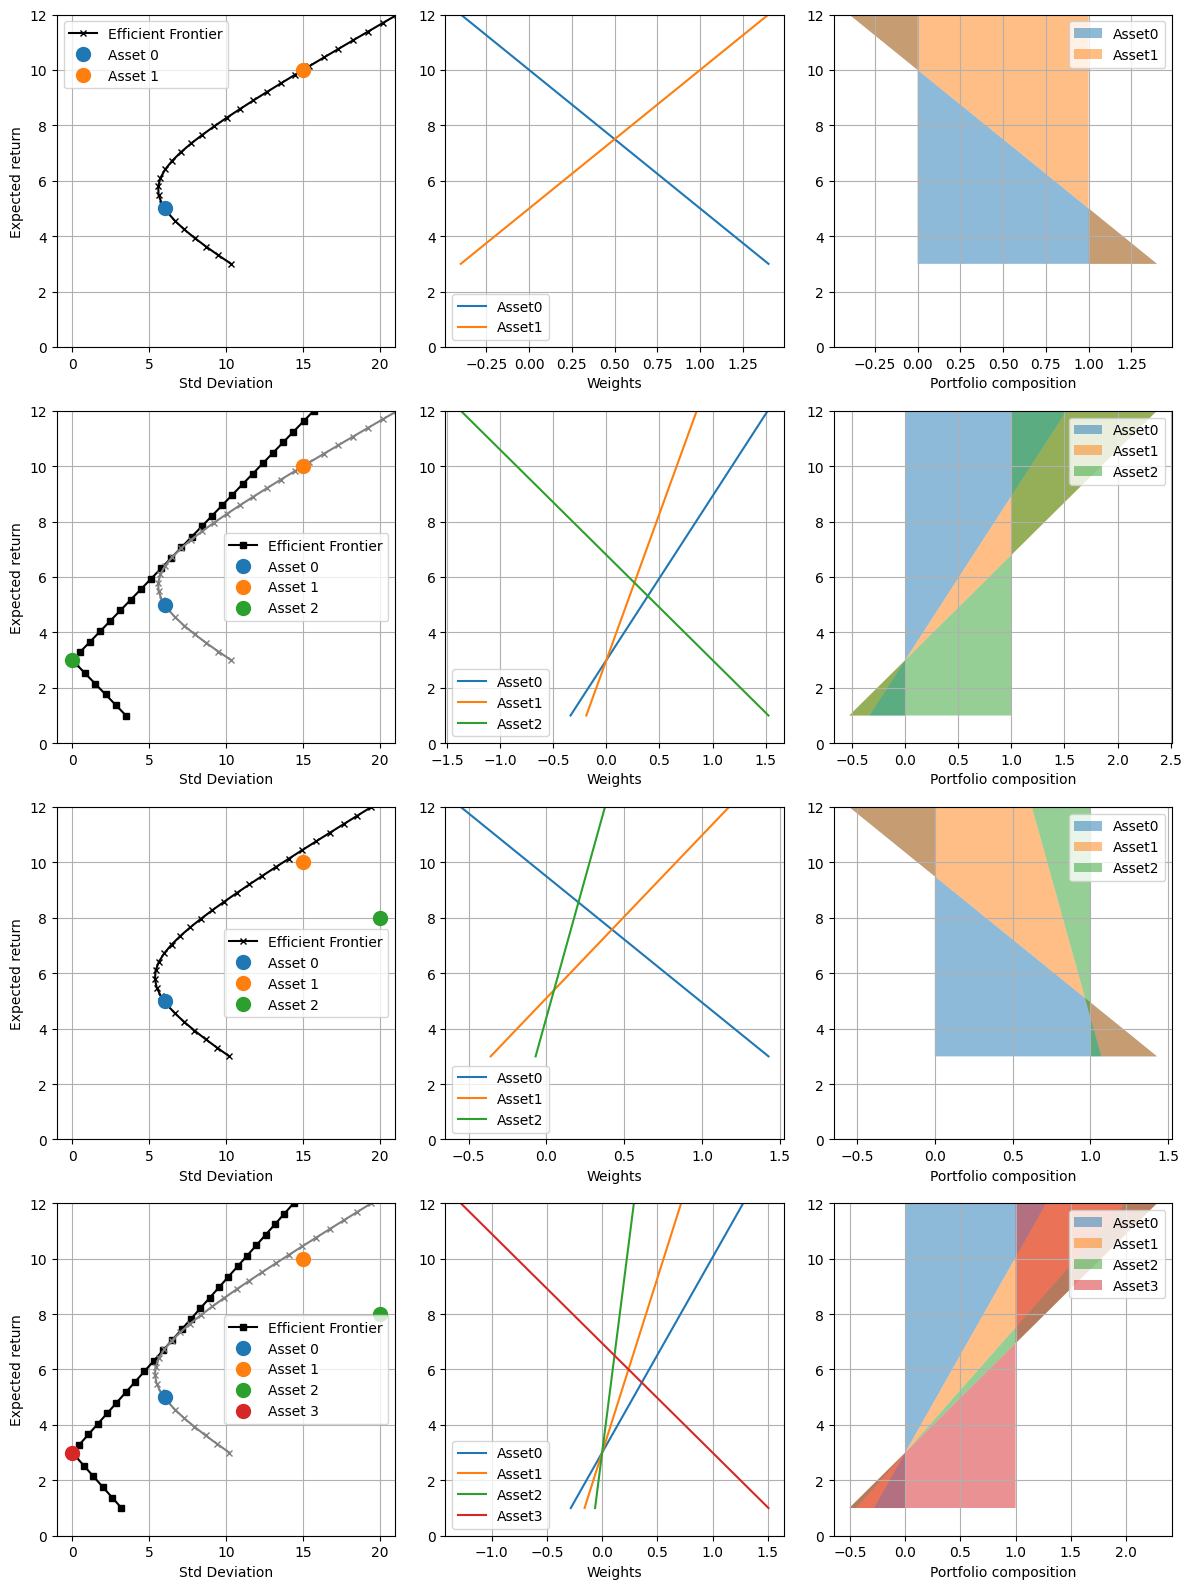

In [6]:
#> Initialize plot
fig, ax = plt.subplots(len(ptfs), 3, figsize=(12, 16))


nptf = 0
for kptf, ptf in ptfs.items():

    #>
    si = ptf["si"]
    mu = ptf["mu"]
    
    # for kptf, ptf in ptfs.items():
    ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret'], ptf['marker']+'-', label='Efficient Frontier', color='black', markersize=5,)
    if ( not ptf['w/o risk-free'] == None ):
        ptf_rf = ptfs[ptf['w/o risk-free']]
        ax[nptf,0].plot(ptf_rf['min_sig'], ptf_rf['des_ret'], ptf_rf['marker']+'-', color='grey', markersize=5,)

    for iass in np.arange(len(mu)):
       ax[nptf,0].plot(si[iass,iass]**.5, mu[iass], 'o', markersize=10, label=f'Asset {iass}')
    
    ax[nptf,0].set_xlim([-1, 21])
    ax[nptf,0].set_ylim([ 0, 12])
    # ax[nptf,0].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,0].set_xlabel("Std Deviation")
    ax[nptf,0].set_ylabel("Expected return")
    ax[nptf,0].grid()
    ax[nptf,0].legend()
    
    #> Weights
    wmat = np.array(ptf['wmat'])

    for i in np.arange(np.shape(wmat)[1]):
        ax[nptf,1].plot(wmat[:,i], ptf['des_ret'], label=f"Asset{i}")

    ax[nptf,1].set_xlabel("Weights")
    ax[nptf,1].legend(); ax[nptf,1].grid()
    # ax[nptf,1].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,1].set_ylim([ 0, 12])

    #> Stacked - with expected return on y
    cum = np.zeros((np.shape(wmat)[0], np.shape(wmat)[1]+1))

    for i in np.arange(1, np.shape(cum)[1]):
        cum[:,i] = cum[:,i-1] + wmat[:,i-1]

    for i in np.arange(1, np.shape(cum)[1]):
        ax[nptf,2].fill_betweenx(ptf['des_ret'], cum[:,i-1], cum[:,i], label=f"Asset{i-1}", alpha = .5)

    ax[nptf,2].legend(); ax[nptf,2].grid()  # loc='upper right'
    ax[nptf,2].set_xlabel('Portfolio composition')
    # ax[nptf,2].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,2].set_ylim([ 0, 12])


    nptf += 1

fig.tight_layout()
plt.show()

(fin-edu:investing:mpt-capm:capm-no-leverage-short)=
## Efficient frontier and CAPM without leverage and short-selling


In [7]:
for kptf, ptf in ptfs.items():

    n_assets = len(ptf['mu'])

    ptf['wmat'] = []
    ptf['min_sig'] = []
    ptf['des_ret'] = np.linspace(np.min(ptf['mu']), np.max(ptf['mu'])+2., 30)

    for desired_ret in ptf['des_ret']:

        #> Constraints (just comment if you don't want some)
        eq_cons = [
            {'type':   'eq', 'fun': partial(eq_desired_return, mu=ptf['mu'], desired_ret=desired_ret)},
            {'type':   'eq', 'fun': eq_weight_sum},     # sum(w) = 1 (fully invested)
        ]
        eq_cons += [ {'type': 'ineq', 'fun': lambda x:   x[i]} for i in np.arange(n_assets) ]
        eq_cons += [ {'type': 'ineq', 'fun': lambda x: 1-x[i]} for i in np.arange(n_assets) ]

        cost_fun = partial(ptf_var, sigma=ptf['si'])

        x0 = np.zeros(n_assets); x0[0] = 1  #  np.ones(3) / 3.
        res = minimize(cost_fun, x0, constraints=eq_cons,)

        # print(f"Desired Return: {desired_ret}, res: {res.x}")

        ptf_si = np.sqrt(res.x @ ptf['si'] @ res.x)
        ptf_mu = np.sum(res.x * ptf['mu'])

        #> Store weights and min variance, for the desired expected return
        ptf['wmat'] += [ res.x ]
        ptf['min_sig'] += [ ptf_si ]




**Plots.**

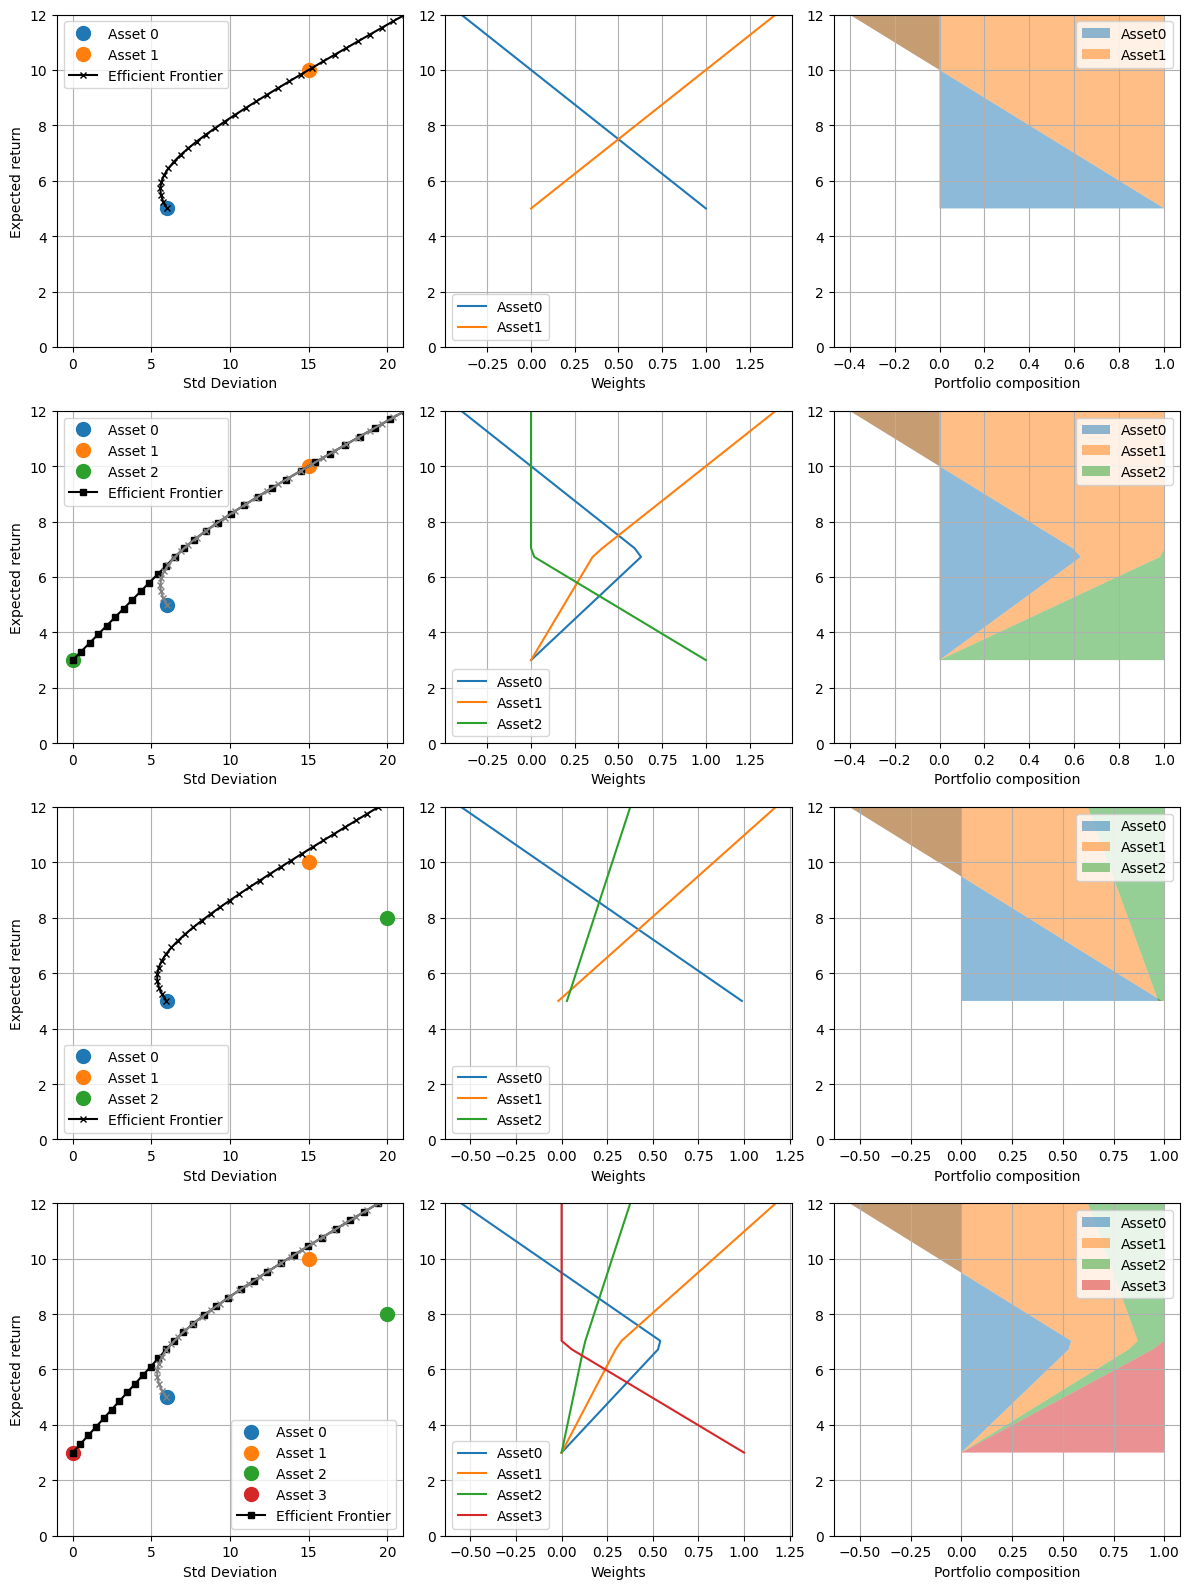

In [8]:
#> Initialize plot
fig, ax = plt.subplots(len(ptfs), 3, figsize=(12, 16))

nptf = 0
for kptf, ptf in ptfs.items():

    #>
    si = ptf["si"]
    mu = ptf["mu"]

    for iass in np.arange(len(mu)):
        ax[nptf,0].plot(si[iass,iass]**.5, mu[iass], 'o', markersize=10, label=f'Asset {iass}')

    # for kptf, ptf in ptfs.items():
    ax[nptf,0].plot(ptf['min_sig'], ptf['des_ret'], ptf['marker']+'-', label='Efficient Frontier', color='black', markersize=5,)
    if ( not ptf['w/o risk-free'] == None ):
        ptf_rf = ptfs[ptf['w/o risk-free']]
        ax[nptf,0].plot(ptf_rf['min_sig'], ptf_rf['des_ret'], ptf_rf['marker']+'-', color='grey', markersize=5,)   
    
    # ax[nptf,0].set_ylim([min_mu-.2, max_mu+.2])
    ax[nptf,0].set_xlim([-1, 21])
    ax[nptf,0].set_ylim([ 0, 12])
    ax[nptf,0].set_xlabel("Std Deviation")
    ax[nptf,0].set_ylabel("Expected return")
    ax[nptf,0].grid()
    ax[nptf,0].legend()
   
    #> Weights
    wmat = np.array(ptf['wmat'])

    for i in np.arange(np.shape(wmat)[1]):
        ax[nptf,1].plot(wmat[:,i], ptf['des_ret'], label=f"Asset{i}")

    ax[nptf,1].set_xlabel("Weights")
    ax[nptf,1].legend(); ax[nptf,1].grid()
    ax[nptf,1].set_ylim([ 0, 12])
    # ax[nptf,1].set_ylim([min_mu-.2, max_mu+.2])

    #> Stacked - with expected return on y
    cum = np.zeros((np.shape(wmat)[0], np.shape(wmat)[1]+1))

    for i in np.arange(1, np.shape(cum)[1]):
        cum[:,i] = cum[:,i-1] + wmat[:,i-1]

    for i in np.arange(1, np.shape(cum)[1]):
        ax[nptf,2].fill_betweenx(ptf['des_ret'], cum[:,i-1], cum[:,i], label=f"Asset{i-1}", alpha = .5)

    ax[nptf,2].legend(); ax[nptf,2].grid()  # loc='upper right'
    ax[nptf,2].set_xlabel('Portfolio composition')
    ax[nptf,2].set_ylim([ 0, 12])
    # ax[nptf,2].set_ylim([min_mu-.2, max_mu+.2])

    nptf += 1

fig.tight_layout()
plt.show()